# Задание 1

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Electronic_sales_Sep2023-Sep2024.csv")

preferred_payment = df.groupby("Customer ID")["Payment Method"] \
                        .agg(lambda x: x.mode()[0]) \
                        .reset_index()

total_spent = df.groupby("Customer ID")["Total Price"].sum().reset_index()

addon_spent = df.groupby("Customer ID")["Add-on Total"].sum().reset_index()

customer_summary = preferred_payment.merge(total_spent, on="Customer ID") \
                                   .merge(addon_spent, on="Customer ID")

customer_summary.rename(columns={
    "Payment Method": "Preferred Payment",
    "Total Price": "Total Spent",
    "Add-on Total": "Add-on Spent"
}, inplace=True)

customer_summary.head(15)


,Customer ID,Preferred Payment,Total Spent,Add-on Spent
0,1000,Credit Card,6279.42,66.30
1,1002,Cash,5020.60,60.16
2,1003,Cash,41.50,35.56
3,1004,Credit Card,83.00,65.78
4,1005,Debit Card,11779.11,75.33
5,1006,Cash,12184.27,133.43
6,1007,Credit Card,7120.71,55.48
7,1008,Cash,3379.32,65.85
8,1011,Credit Card,7911.90,70.17
9,1013,Paypal,5538.33,57.81


# Задание 2

## по каждому методу доставки

In [32]:
revenue_by_shipping = df.groupby("Shipping Type")["Total Price"].sum().reset_index()
revenue_by_shipping.head(15)

,Shipping Type,Total Price
0,Expedited,12437526.21
1,Express,8685215.62
2,Overnight,8704828.17
3,Same Day,12432024.82
4,Standard,21343073.55


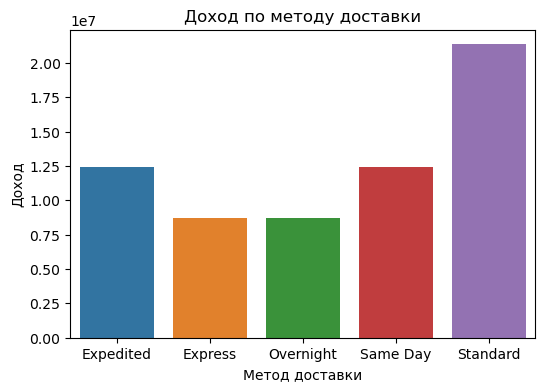

In [33]:
plt.figure(figsize=(6,4))
sns.barplot(x='Shipping Type', y='Total Price', data=revenue_by_shipping)
plt.title("Доход по методу доставки")
plt.ylabel("Доход")
plt.xlabel("Метод доставки")
plt.show()

## по каждому типу продукта

In [34]:
revenue_by_product = df.groupby("Product Type")["Total Price"].sum().reset_index()
revenue_by_product.head(10)

,Product Type,Total Price
0,Headphones,4041400.24
1,Laptop,12296239.97
2,Smartphone,21516754.69
3,Smartwatch,14036273.06
4,Tablet,11712000.41


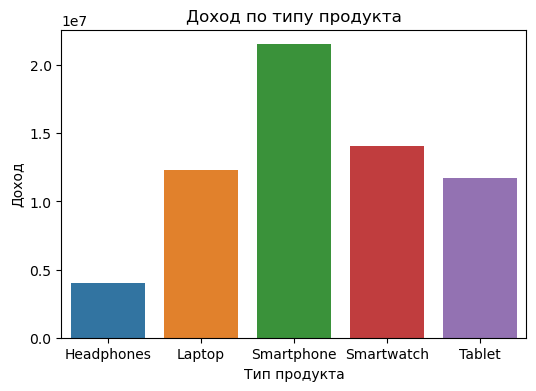

In [35]:
plt.figure(figsize=(6,4))
sns.barplot(x='Product Type', y='Total Price', data=revenue_by_product)
plt.title("Доход по типу продукта")
plt.ylabel("Доход")
plt.xlabel("Тип продукта")
plt.show()

## по дополнительным услугам за каждый месяц

In [36]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df['Month'] = df['Purchase Date'].dt.to_period('M')


addon_monthly = df.groupby('Month')['Add-on Total'].sum().reset_index()

addon_monthly['Month'] = addon_monthly['Month'].astype(str)


addon_monthly.head(20)


,Month,Add-on Total
0,2023-09,8012.62
1,2023-10,37837.12
2,2023-11,34888.81
3,2023-12,33509.15
4,2024-01,136195.16
5,2024-02,120148.92
6,2024-03,124954.26
7,2024-04,123973.59
8,2024-05,132018.51
9,2024-06,126689.59


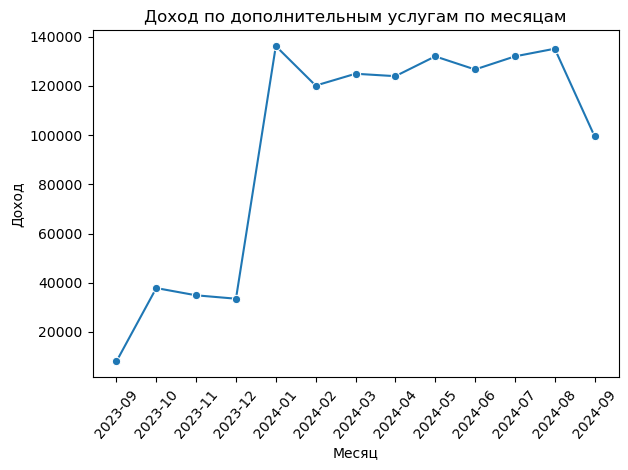

In [37]:
sns.lineplot(x='Month', y='Add-on Total', data=addon_monthly, marker='o')
plt.title("Доход по дополнительным услугам по месяцам")
plt.ylabel("Доход")
plt.xlabel("Месяц")
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

## по дополнительным услугам за каждый квартал 

In [38]:
df['Quarter'] = df['Purchase Date'].dt.to_period('Q')

addon_quarterly = df.groupby('Quarter')['Add-on Total'].sum().reset_index()
addon_quarterly.head(10)

,Quarter,Add-on Total
0,2023Q3,8012.62
1,2023Q4,106235.08
2,2024Q1,381298.34
3,2024Q2,382681.69
4,2024Q3,366669.23


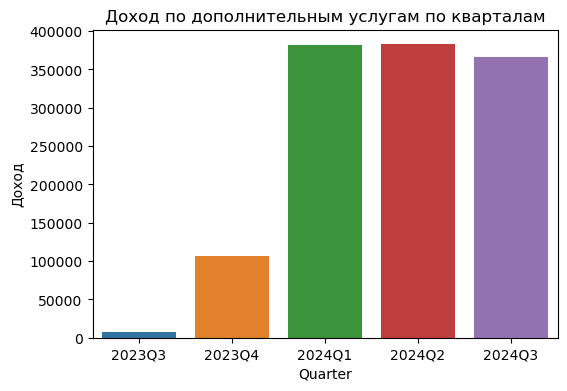

In [39]:
plt.figure(figsize=(6,4))
sns.barplot(x='Quarter', y='Add-on Total', data=addon_quarterly)
plt.title("Доход по дополнительным услугам по кварталам")
plt.ylabel("Доход")
plt.show()